# Irwin-Hall Distribution

`IrwinHall(n, a, b)` is the distribution of the **sum** of `n` independent uniform values. With the default bounds that is `Uniform(0, 1) + Uniform(0, 1) + ...` added up `n` times, so the possible totals run from 0 to `n`. Pass `a` and `b` to add uniforms on some other interval instead.

It is the standard way to watch the Central Limit Theorem happen with the simplest ingredient there is: one uniform is flat, two make a triangle, three already look rounded, and by a dozen the density is almost a normal curve -- even though no single piece of the sum resembles one.

Its companion is `Bates`, the *mean* of `n` uniforms rather than their sum; the two are compared at the end of this notebook.

In [1]:
from symbulate import *

## Draw a value from an Irwin-Hall distribution

In [2]:
IrwinHall(n=5).draw()

3.668992187133518

## Theoretical mean, variance, and standard deviation

The pieces are independent, so the mean and variance are just `n` times those of a single uniform: `n * (a + b) / 2` and `n * (b - a) ** 2 / 12`.

In [3]:
IrwinHall(n=5).mean(), IrwinHall(n=5).var(), IrwinHall(n=5).sd()

(np.float64(2.5),
 np.float64(0.4166666666666667),
 np.float64(0.6454972243679028))

In [4]:
5 * (0 + 1) / 2, 5 * (1 - 0) ** 2 / 12

(2.5, 0.4166666666666667)

## Assign and simulate a random variable

In [5]:
X = RV(IrwinHall(n=5))
X.sim(10000)

0,3.1817362166604704
1,2.8097651558353154
2,3.526551988118425
3,2.504502620874943
4,2.7506438780742624
5,1.8415543636858782
6,2.7932723187721433
7,2.135232913997382
8,2.6970958423969664
...,...
9999,3.3158516783105325


## Plot the pdf

The support is all of `[0, 5]` -- five uniforms *could* all land near 0, or all near 1 -- but that takes a coincidence, so the density bunches up in the middle.

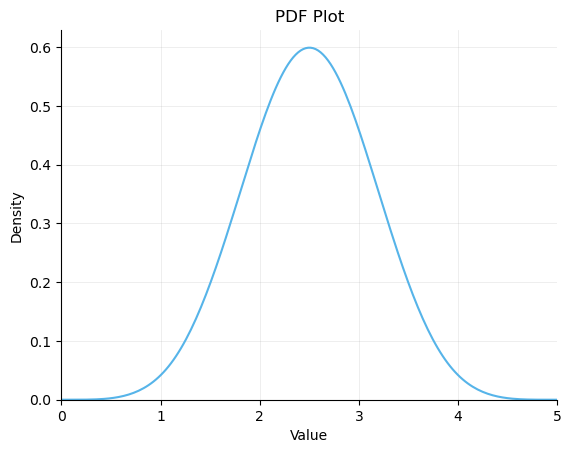

In [6]:
IrwinHall(n=5).plot()

## Plot the CDF

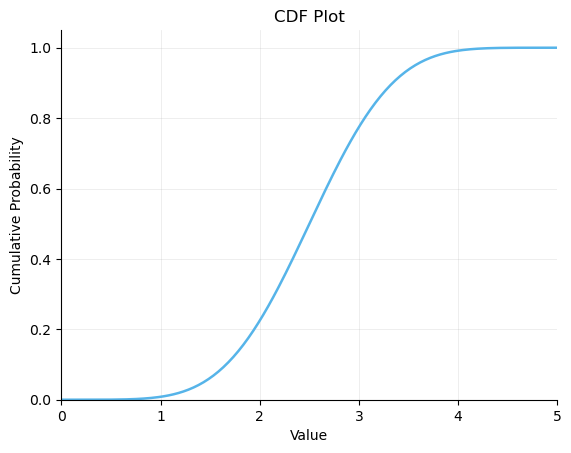

In [7]:
IrwinHall(n=5).plot(cdf=True)

## Simulated values against the theoretical curve

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


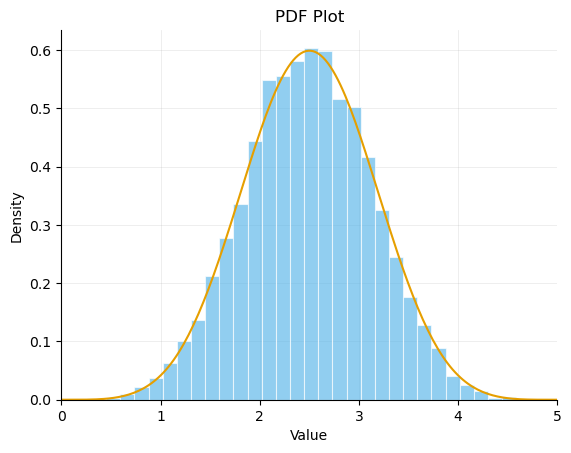

In [8]:
X.sim(10000).plot()
IrwinHall(n=5).plot()

## The defining property: it *is* the sum of n uniforms

Simulate three independent `Uniform(0, 1)` values, add them up, and the histogram lands on the `IrwinHall(n=3)` density.

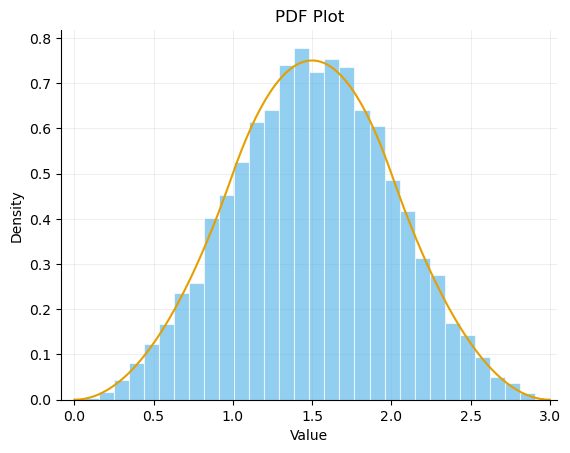

In [9]:
U1, U2, U3 = RV(Uniform(0, 1) ** 3)
(U1 + U2 + U3).sim(10000).plot()
IrwinHall(n=3).plot()

## Watching the Central Limit Theorem, one uniform at a time

`n = 1` is flat, `n = 2` is a triangle with a sharp corner, `n = 3` is already visibly rounded, and by `n = 12` it is hard to tell from a bell curve. Nothing about a single uniform hints at this -- the shape comes entirely from the counting: there are many ways to reach a middling total and very few ways to reach an extreme one.

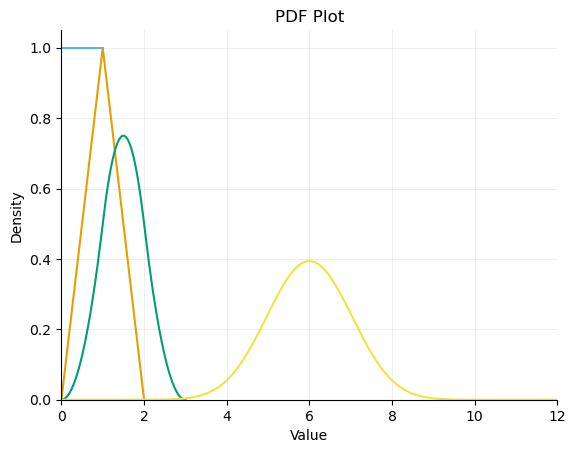

In [10]:
for n in [1, 2, 3, 12]:
    IrwinHall(n=n).plot()

Two of those cases are distributions we already have names for. `n = 1` is exactly `Uniform(0, 1)`, and `n = 2` is exactly `Triangular(0, 1, 2)`.

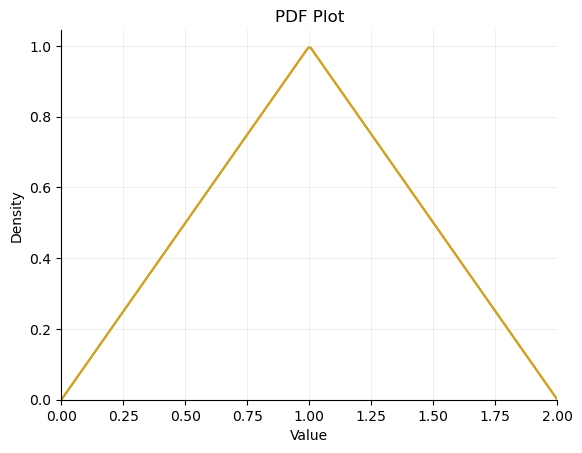

In [11]:
IrwinHall(n=2).plot()
Triangular(low=0, mode=1, high=2).plot()

## The n = 12 special case

`IrwinHall(n=12)` has mean 6 and variance *exactly* 1, so `IrwinHall(n=12) - 6` is a well-known cheap stand-in for a standard normal value -- and the two densities are nearly indistinguishable. The agreement is not perfect: the Irwin-Hall sum can never leave `[0, 12]`, while a normal value has no bounds at all, so the normal curve keeps a little probability out in the tails that the sum simply cannot reach.

In [12]:
IrwinHall(n=12).mean(), IrwinHall(n=12).var()

(np.float64(6.0), np.float64(1.0))

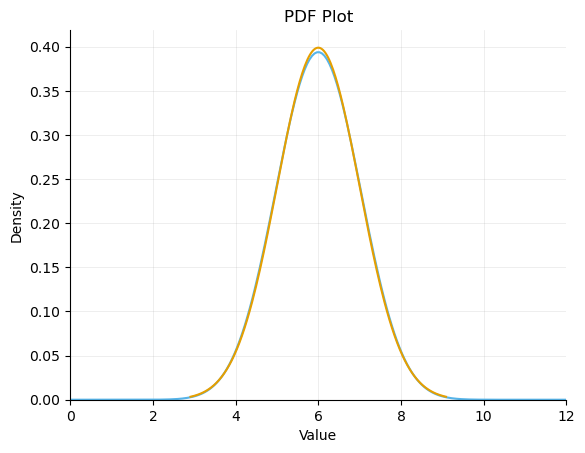

In [13]:
IrwinHall(n=12).plot()
Normal(mean=6, sd=1).plot()

In [14]:
# The tails are where the two part ways.
float(IrwinHall(n=12).cdf(2)), float(Normal(mean=6, sd=1).cdf(2))

(8.526067553845333e-06, 3.167124183311986e-05)

## Adding uniforms on some other interval

`a` and `b` are the bounds of each uniform being added, not of the sum. Four values uniform on `[10, 20]` add up to a total somewhere in `[40, 80]`.

In [15]:
Y = IrwinHall(n=4, a=10, b=20)
Y.mean(), Y.sd()

(np.float64(60.0), np.float64(5.773502691896257))

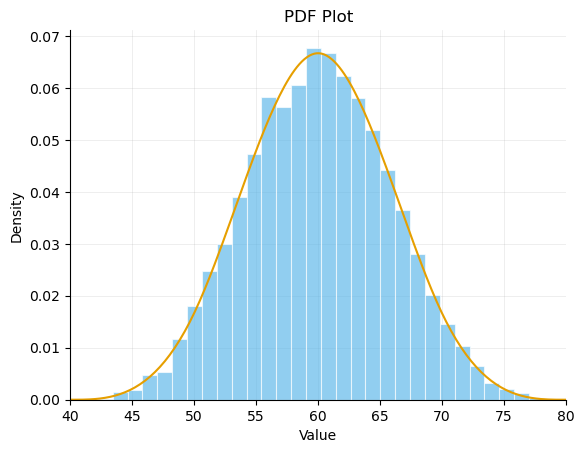

In [16]:
RV(Y).sim(10000).plot()
Y.plot()

## Spread grows slower than the range

Notice how the density gets *relatively* narrower as `n` grows. The standard deviation grows like the square root of `n` while the support grows like `n`, so the sum occupies less and less of the range it is allowed. Framing a large `n` on its full support wastes most of the plot; `xlim="zoom"` frames the part where the probability actually lives.

In [17]:
[(n, round(float(IrwinHall(n=n).sd()) / n, 4)) for n in [1, 4, 16, 64]]

[(1, 0.2887), (4, 0.1443), (16, 0.0722), (64, 0.0361)]

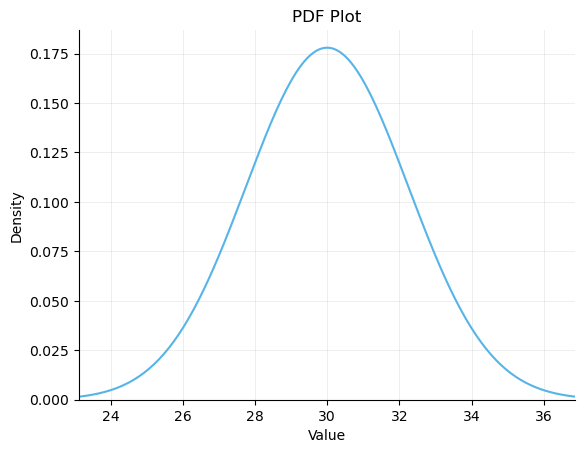

In [18]:
IrwinHall(n=60).plot(xlim="zoom")

## Related: the *average* of n uniforms

Divide the sum by `n` and you get the average of the `n` uniform values, which is its companion distribution `Bates`. Simulating `IrwinHall(n=12) / 12` lands on the `Bates(n=12)` density.

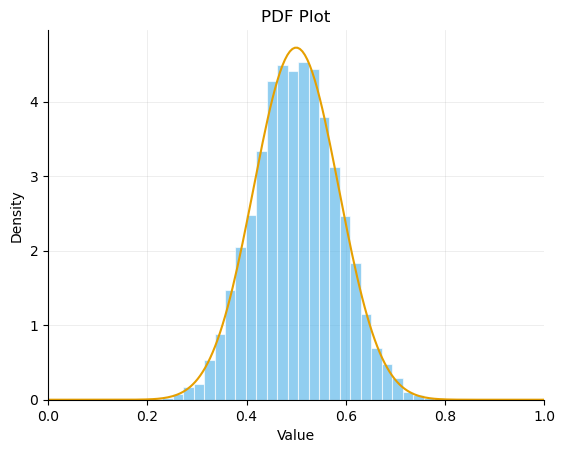

In [19]:
(RV(IrwinHall(n=12)) / 12).sim(10000).plot()
Bates(n=12).plot()

The two say the same thing on different scales. The sum spreads out as `n` grows -- it lives on `[0, n]` -- while the average stays on `[0, 1]` and tightens around 0.5, which is the Law of Large Numbers sitting right next to the Central Limit Theorem above. Use `IrwinHall` when the total is what matters and `Bates` when the average is.

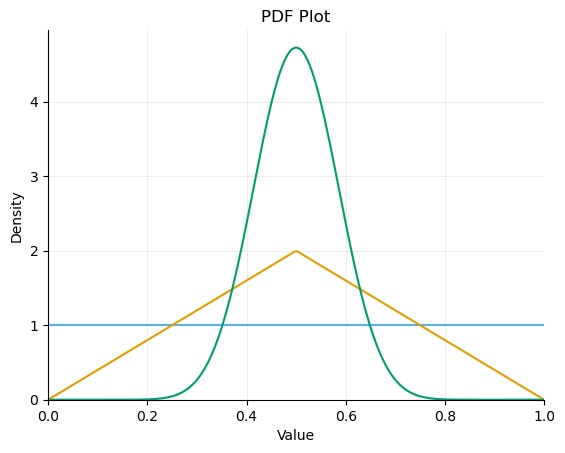

In [20]:
for n in [1, 2, 12]:
    Bates(n=n).plot()